In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os   

from tkinter import Tk
from tkinter.filedialog import askopenfilenames

import os

C:\Users\ppita\AppData\Local\Temp\ipykernel_50916\2829857814.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_50916\2829857814.py:51: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_50916\2829857814.py:89: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ho

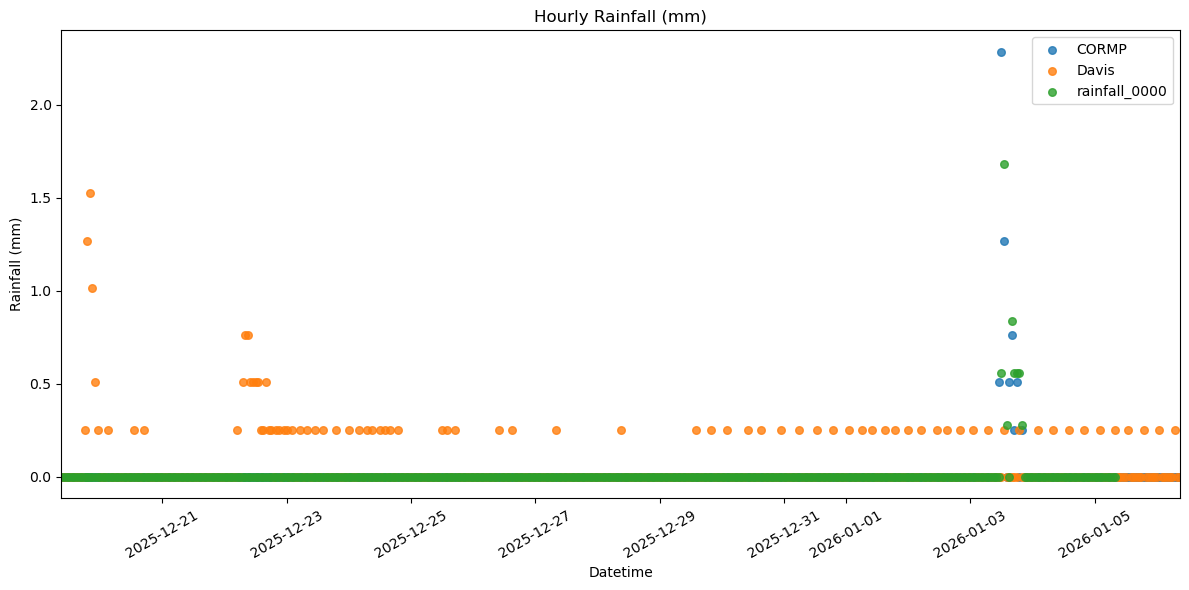

In [ ]:
file_1 = "Data/precip_CORMP_01062026.csv"   # needs hourly sum
file_2 = "Data/precip_Davis_01062026.csv"   # needs hourly sum
file_3 = "Data/rainfall_0000_01062026.csv"   # already hourly

import io

import re

def detect_header_row(path, max_lines=200):
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= max_lines:
                break
            low = line.lower()
            # heuristic: header lines usually contain 'date' or 'time' and a comma
            if (('date' in low or 'time' in low) and ',' in line) or ('date &' in low):
                return i
    return 0


def load_and_process(filepath, assume_inches=False, already_hourly=False):
    path = os.path.join(filepath)
    header_row = detect_header_row(path, max_lines=200)
    try:
        # set header to detected row; also skip percent-comment lines
        df = pd.read_csv(path, header=header_row, comment='%', engine='python')
    except Exception as e:
        print(f"read_csv failed for {path}: {e}")
        df = pd.read_csv(path, engine='python', sep=None, on_bad_lines='warn')

    # ensure column names are strings
    df.columns = [str(c) for c in df.columns]

    # find datetime column by keywords or by attempting to parse columns
    datetime_cols = [c for c in df.columns if any(k in c.lower() for k in ('date','time','datetime','timestamp'))]
    dtcol = None
    if datetime_cols:
        dtcol = datetime_cols[0]
    else:
        for c in df.columns:
            try:
                parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
                if parsed.notna().sum() > 0:
                    dtcol = c
                    break
            except Exception:
                continue
    if dtcol is None:
        raise ValueError(f"No datetime-like column found in {filepath}")

    df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)

    # find rainfall column
    rain_cols = [c for c in df.columns if any(k in c.lower() for k in ('rain','precip','mm','inches'))]
    if rain_cols:
        rcol = rain_cols[0]
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        rcol = numeric_cols[0] if numeric_cols else None

    if rcol is None:
        for c in df.columns:
            coerced = pd.to_numeric(df[c], errors='coerce')
            if coerced.notna().sum() > 0:
                rcol = c
                df[c] = coerced
                break
    if rcol is None:
        raise ValueError(f"No rainfall/numeric column found in {filepath}")

    df[rcol] = pd.to_numeric(df[rcol], errors='coerce')
    if assume_inches:
        df[rcol] = df[rcol] * 25.4

    subset_cols = [c for c in ['datetime', rcol] if c in df.columns]
    df = df.dropna(subset=subset_cols)

    if 'datetime' in df.columns:
        df = df.set_index('datetime')
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise KeyError('datetime')

    if already_hourly:
        hourly = df.reset_index().rename(columns={rcol: 'rain_mm'})
        if 'datetime' not in hourly.columns:
            hourly = hourly.rename(columns={hourly.columns[0]: 'datetime'})
    else:
        hourly = df[rcol].resample('H').sum().reset_index().rename(columns={rcol: 'rain_mm'})
    return hourly

# process files
cormp = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis = load_and_process(file_2, assume_inches=True, already_hourly=False)
rain0 = load_and_process(file_3, assume_inches=False, already_hourly=True)

# restrict to requested date range
start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-06 09:00')

cormp = cormp[(cormp['datetime'] >= start) & (cormp['datetime'] <= end)].reset_index(drop=True)
davis = davis[(davis['datetime'] >= start) & (davis['datetime'] <= end)].reset_index(drop=True)
rain0 = rain0[(rain0['datetime'] >= start) & (rain0['datetime'] <= end)].reset_index(drop=True)

# compute R^2 between Davis and rainfall_0000 (align on datetime)
merged_dr = pd.merge(davis, rain0, on='datetime', how='inner', suffixes=('_davis','_rain0'))
if not merged_dr.empty:
    corr = merged_dr['rain_mm_davis'].corr(merged_dr['rain_mm_rain0'])
    r2_davis_rain0 = corr**2 if pd.notna(corr) else float('nan')
else:
    r2_davis_rain0 = float('nan')

plt.figure(figsize=(12,6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='CORMP', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Davis', s=30, alpha=0.8)
if not rain0.empty:
    plt.scatter(rain0['datetime'], rain0['rain_mm'], label='rainfall_0000', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Hourly Rainfall (mm)')
plt.legend()
plt.xlim(start, end)

# annotate R^2 on the plot (Davis vs rainfall_0000) using axis coords for visibility
try:
    ax = plt.gca()
    if pd.notna(r2_davis_rain0):
        ax.text(0.02, 0.95, f'$R^2 = {r2_davis_rain0:.2f}$', transform=ax.transAxes, fontsize=11, va='top')
except Exception:
    pass

plt.xticks(rotation=30)
plt.tight_layout()


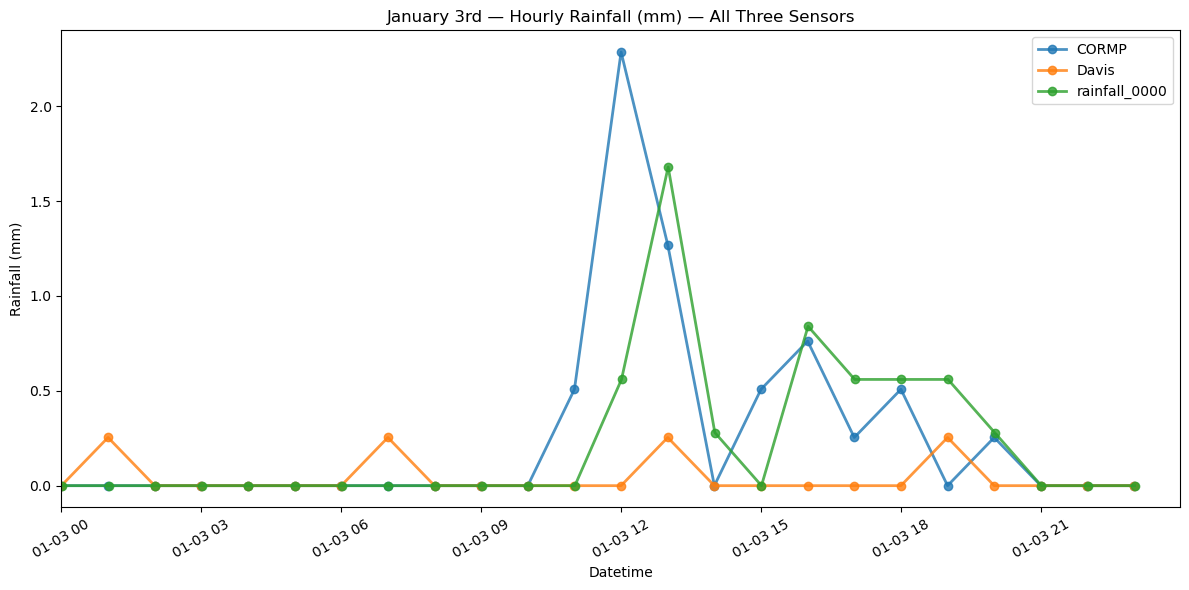

In [10]:
# Plot all three files for January 3rd only
jan3_start = pd.to_datetime('2026-01-03 00:00')
jan3_end = pd.to_datetime('2026-01-03 23:59')

cormp_jan3 = cormp[(cormp['datetime'] >= jan3_start) & (cormp['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis[(davis['datetime'] >= jan3_start) & (davis['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0[(rain0['datetime'] >= jan3_start) & (rain0['datetime'] <= jan3_end)].reset_index(drop=True)

plt.figure(figsize=(12,6))
if not cormp_jan3.empty:
    plt.plot(cormp_jan3['datetime'], cormp_jan3['rain_mm'], label='CORMP', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not davis_jan3.empty:
    plt.plot(davis_jan3['datetime'], davis_jan3['rain_mm'], label='Davis', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not rain0_jan3.empty:
    plt.plot(rain0_jan3['datetime'], rain0_jan3['rain_mm'], label='rainfall_0000', marker='o', linewidth=2, markersize=6, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('January 3rd — Hourly Rainfall (mm) — All Three Sensors')
plt.legend()
plt.xlim(jan3_start, jan3_end)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\ppita\AppData\Local\Temp\ipykernel_50916\2829857814.py:51: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_50916\2829857814.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_50916\2829857814.py:89: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df[rcol].resample('H').sum().reset_index().rename(columns={r

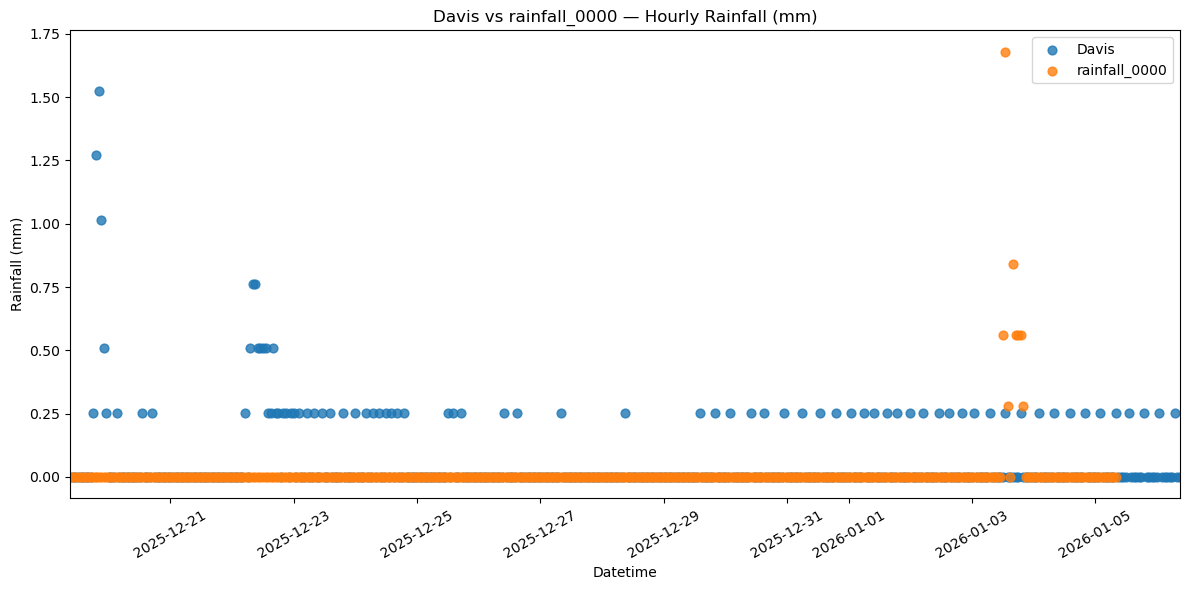

In [5]:
# Compare only `precip_Davis` and `rainfall_0000`
# This re-uses `load_and_process` defined above to produce hourly series and then plots them

# produce hourly series (these calls are quick since files are already read earlier, but keep them for standalone use)
davis_only = load_and_process(file_2, assume_inches=True, already_hourly=False)
rain0_only = load_and_process(file_3, assume_inches=False, already_hourly=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-06 09:00')

davis_only = davis_only[(davis_only['datetime'] >= start) & (davis_only['datetime'] <= end)].reset_index(drop=True)
rain0_only = rain0_only[(rain0_only['datetime'] >= start) & (rain0_only['datetime'] <= end)].reset_index(drop=True)

# compute R^2 between Davis and rainfall_0000 (align on datetime)
merged_dr_only = pd.merge(davis_only, rain0_only, on='datetime', how='inner', suffixes=('_davis','_rain0'))
if not merged_dr_only.empty:
    corr_only = merged_dr_only['rain_mm_davis'].corr(merged_dr_only['rain_mm_rain0'])
    r2_only = corr_only**2 if pd.notna(corr_only) else float('nan')
else:
    r2_only = float('nan')

plt.figure(figsize=(12,6))
if not davis_only.empty:
    plt.scatter(davis_only['datetime'], davis_only['rain_mm'], label='Davis', s=40, alpha=0.8)
if not rain0_only.empty:
    plt.scatter(rain0_only['datetime'], rain0_only['rain_mm'], label='rainfall_0000', s=40, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Davis vs rainfall_0000 — Hourly Rainfall (mm)')
plt.legend()
plt.xlim(start, end)

# annotate R^2 using axis coords
try:
    ax = plt.gca()
    if pd.notna(r2_only):
        ax.text(0.02, 0.95, f'$R^2 = {r2_only:.2f}$', transform=ax.transAxes, fontsize=11, va='top')
except Exception:
    pass

plt.xticks(rotation=30)
plt.tight_layout()


R^2 (Davis vs rainfall_0000) [main plot]: nan
R^2 (Davis vs rainfall_0000) [Davis-only plot]: nan
